# South Korea Solow-Swan and R-C-K model

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install statsmodels



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.5 MB 8.4 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/36.5 MB 11.5 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/36.5 MB 12.3 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.5 MB 12.1 MB/s eta 0:00:03
   -------------- ------------------------- 13.1/36.5 MB 11.9 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/36.5 MB 11.4 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/36.5 MB 11.2 MB/s eta 0:00:02
   ---------------------- ----------------- 20.2/36.5 MB 11.5 MB/s eta 0:00:02
   ------------------------- -------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import requests


In [4]:
# read the excel file 
df = pd.read_excel(r'C:\Users\dell\OneDrive\Documents\SSE\GD\pwt110.xlsx', sheet_name= 'Sheet2')

In [5]:
df.index = pd.PeriodIndex(df['year'], freq='Y')
df.drop(columns=['year'], inplace=True)


In [6]:
df.columns


Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf'],
      dtype='object')

# barro regression


In [7]:
# tacking log of the level variable
df['log_rgdpo'] = np.log(df['rgdpo'])
df['log_rgdpe'] = np.log(df['rgdpe'])
# lag of the log variable
df['log_rgdpo_lag1'] = df['log_rgdpo'].shift(1)
df['log_rgdpe_lag1'] = df['log_rgdpe'].shift(1)

# growth rate of the level variable
df['rgdpo_growth'] = df['log_rgdpo'] - df['log_rgdpo_lag1']
df['rgdpe_growth'] = df['log_rgdpe'] - df['log_rgdpe_lag1']

In [8]:
# unconditional regression
X = df['log_rgdpo_lag1']# independent variable 
y = df['rgdpo_growth'] # dependent variable

# add a constant to the independent variable
X = sm.add_constant(X)

unc_model = sm.OLS(y, X, missing='drop').fit(cov_type='HC3')
print(unc_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpo_growth   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     8.551
Date:                Tue, 17 Mar 2026   Prob (F-statistic):            0.00477
Time:                        17:41:44   Log-Likelihood:                 99.180
No. Observations:                  66   AIC:                            -194.4
Df Residuals:                      64   BIC:                            -190.0
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2405      0.061      3.

In [9]:
df['gfcf'] = pd.to_numeric(df['gfcf'], errors='coerce')
df['export'] = pd.to_numeric(df['export'], errors='coerce')
df['trade'] = pd.to_numeric(df['trade'], errors='coerce')

# creating other variables for the regression
df['emp_growth'] = np.log(df['emp']) - np.log(df['emp'].shift(1))
df['log_gfcf'] = np.log(df['gfcf'])
# creating (n+g+delta) variable
df['n_g_delta'] = df['emp_growth'] + df['rtfpna'] + df['delta']
df['log_n_g_delta'] = np.log(df['n_g_delta'])


# conditional regression
X_cond = df[['log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']] # independent variables

#per capita output growth as the dependent variable
df['rgdpo_capita'] = df['rgdpo'] / df['emp']
df['rgdpe_capita'] = df['rgdpe'] / df['emp']

y_cond = df['rgdpo_growth'] # dependent variable
x_cond = sm.add_constant(X_cond)



In [10]:
print(x_cond.dtypes)

const             float64
log_rgdpo_lag1    float64
log_n_g_delta     float64
log_gfcf          float64
dtype: object


In [11]:
cond_model = sm.OLS(y_cond, x_cond, missing='drop').fit(cov_type='HC3')
print(cond_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpo_growth   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     12.06
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.79e-06
Time:                        17:41:44   Log-Likelihood:                 113.04
No. Observations:                  64   AIC:                            -218.1
Df Residuals:                      60   BIC:                            -209.4
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.0416      0.475      2.

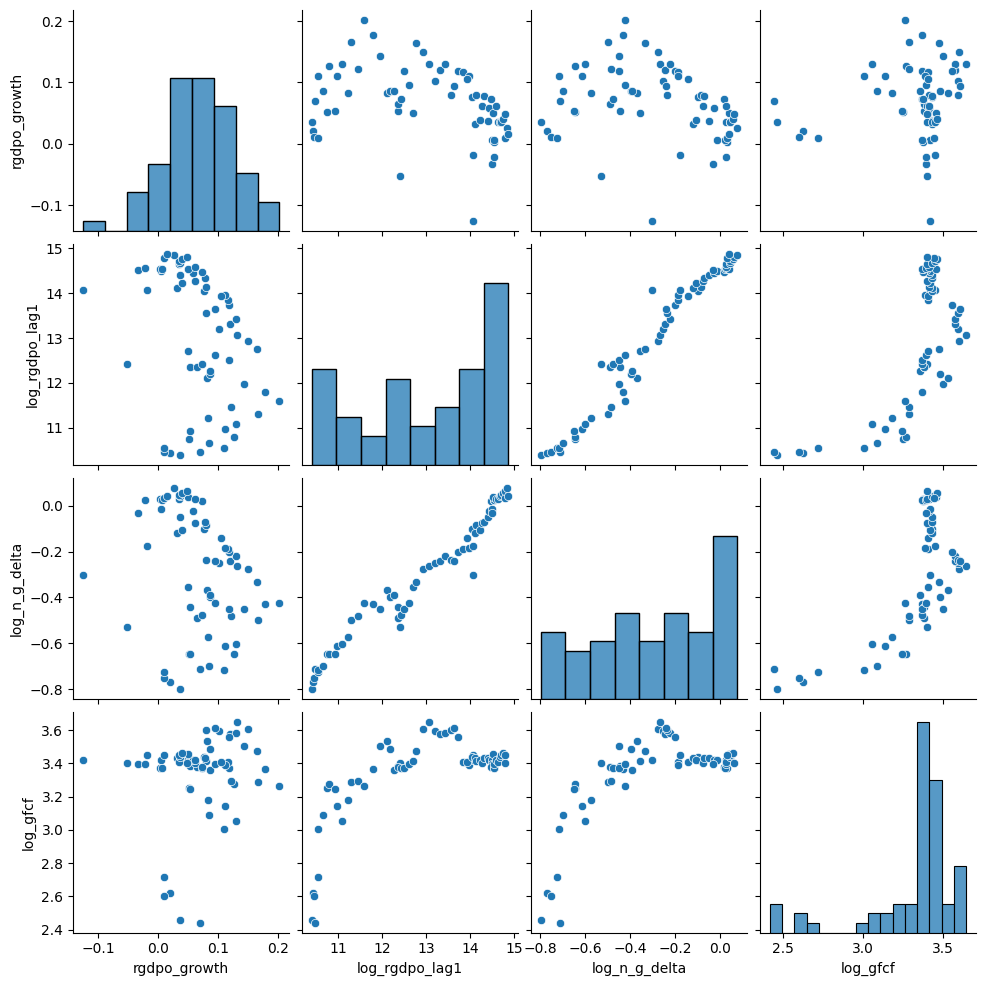

In [12]:
# relationship between each independent variable and the dependent variable
sns.pairplot(df[['rgdpo_growth', 'log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']])
plt.show()

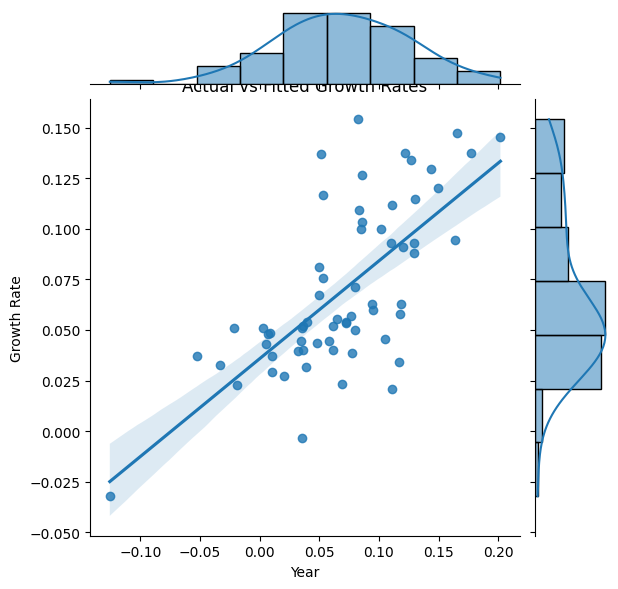

In [13]:
# plot fitted and actual values actter and line graph
df['fitted_values'] = cond_model.fittedvalues
sns.jointplot(x=df['rgdpo_growth'], y=df['fitted_values'], kind='reg')
plt.title('Actual vs Fitted Growth Rates') 
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.show()

In [14]:
df['rgdpo']/1000

year
1957      32.951555
1958      34.157445
1959      34.862094
1960      35.214727
1961      37.728672
           ...     
2019    2638.620500
2020    2665.119500
2021    2795.993500
2022    2869.278750
2023    2912.405500
Freq: Y-DEC, Name: rgdpo, Length: 67, dtype: float64

### Distribution of real GDP

C:\Users\dell\AppData\Local\Temp\ipykernel_19728\1578337918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rgdpo'], label='Data Points');


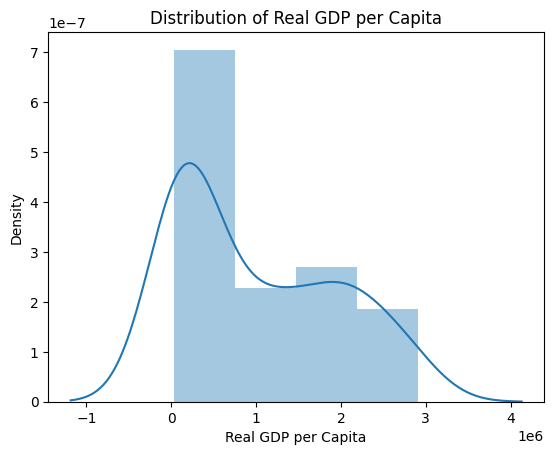

In [15]:
sns.distplot(df['rgdpo'], label='Data Points');
plt.title('Distribution of Real GDP per Capita')
plt.xlabel('Real GDP per Capita') 
plt.ylabel('Density')
plt.show()

#### production function

In [16]:
df.columns

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'log_rgdpo', 'log_rgdpe', 'log_rgdpo_lag1',
       'log_rgdpe_lag1', 'rgdpo_growth', 'rgdpe_growth', 'emp_growth',
       'log_gfcf', 'n_g_delta', 'log_n_g_delta', 'rgdpo_capita',
       'rgdpe_capita', 'fitted_values'],
      dtype='object')

In [17]:
# to identify alpha,beta 
df['log_emp'] = np.log(df['emp'])
df['log_capital'] = np.log(df['rnna'])

x_pro = df[['log_capital', 'log_emp']]
x_pro = sm.add_constant(x_pro)
y_pro = np.log(df['rgdpo'])

pro_model = sm.OLS(y_pro, x_pro, missing='drop').fit(cov_type='HC3')
print(pro_model.summary())



                            OLS Regression Results                            
Dep. Variable:                  rgdpo   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     9611.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.67e-80
Time:                        17:41:52   Log-Likelihood:                 74.195
No. Observations:                  67   AIC:                            -142.4
Df Residuals:                      64   BIC:                            -135.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3238      0.174     13.346      

In [18]:
# alpha, beta and A
df['alpha'] = pro_model.params['log_capital']
df['beta'] = pro_model.params['log_emp']
# A = pro_model.params['const']
A = df['rtfpna'].mean()  # Using the average TFP as a proxy for A
print(A)
# alpha = 0.33

0.7081076391597292


In [19]:
# labour-augmenting production function

def production_function(K, L):
    return (K ** alpha) *  (L ** (1-alpha))
predicted_output = production_function(df['rnna'], df['emp'])
print(predicted_output)

# labour-augmenting production function


def production_function_per_capita(K, L):
    return A ** (1 - alpha) * (K ** alpha)
predicted_output_per_capita = production_function_per_capita(df['rnna'], df['emp'])
print(predicted_output_per_capita)

# actual vs predicted values
df['y_actual'] = (df['rgdpo']/1000) / df['emp']
df['k_actual'] = (df['rnna']/1000) / df['emp']

plt.plot(df['k_actual'], df['y_actual'], label='Actual Data', marker='o', linestyle='None')
plt.plot(df['k_actual'], predicted_output_per_capita, color='red', label='Estimated Production Function')
plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function: South Korea")
plt.legend()
plt.show()

NameError: name 'alpha' is not defined

In [ ]:


# per capita capital

df['y_actual'] = (df['rgdpo']/1000) / df['emp']
df['k_actual'] =  (df['rnna']/1000) / df['emp']
print(df['k_actual'])

k_range = np.linspace(0.1, 10 , 200)

# per capita output
def output_per_capita():
    return A ** (1 - alpha) * (df['k_actual'] ** alpha)
y_per_capita = output_per_capita()
print(y_per_capita)

# average of the n, g and delta for constant break-even investment
emp_growth_avg = df['emp_growth'].mean()
rtfpna_avg = df['rtfpna'].mean()
delta_avg = df['delta'].mean()
n_g_delta_avg = emp_growth_avg + rtfpna_avg

# break-even investment
def break_even_investment():
    return (n_g_delta_avg * k_actual)
break_even = break_even_investment()
print(break_even)


print(n_g_delta_avg)


NameError: name 'df' is not defined

### solow curve

In [ ]:
pip install sympy

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.3 MB 2.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.6/6.3 MB 3.4 MB/s eta 0:00:02
   -------------- ------------------------- 2.4/6.3 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.1/6.3 MB 3.6 MB/s eta 0:00:01
   ----------------------- ---------------- 3.7/6.3 MB 3.3 MB/s eta 0:00:01
   ---------------------------- ----------- 4.5/6.3 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 5.2/6.3 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------  6.3/6.3 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 3.4 MB/s  0:00:01
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 3.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 

In [ ]:
# saving rate
import sympy as sp
df['s'] = df['saving_rate'] = (df['gfcf']/100)
s_mean = df['s'].mean()

print(s_mean)

# s into f of k
def s_f_k():
    return df['s'] * y_per_capita
s_f_k_values = s_f_k()
print(s_f_k_values)

0.28578297207949194
year
1957    0.233215
1958    0.242037
1959    0.282721
1960    0.274335
1961    0.231917
          ...   
2019    1.537792
2020    1.532506
2021    1.472151
2022         NaN
2023         NaN
Freq: Y-DEC, Length: 67, dtype: float64


<Axes: xlabel='year', ylabel='k_actual'>

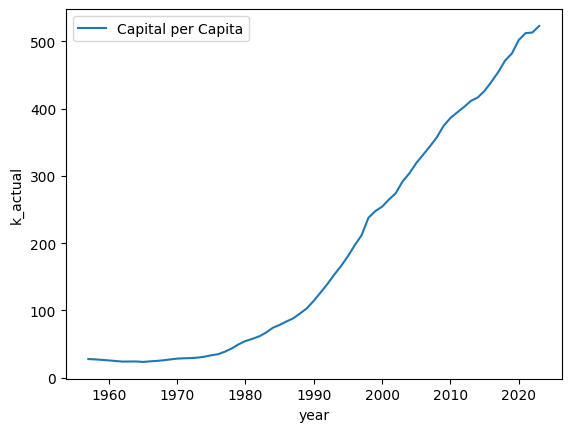

In [ ]:
sns.lineplot(x = df.index.to_timestamp(), y = df['k_actual'], label='Capital per Capita')

Text(0, 0.5, 'Output / Investment per Worker')

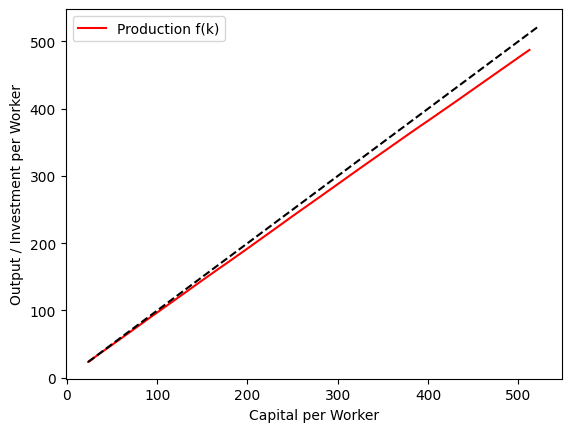

In [ ]:
y_curve = (df['s'] * (df['k_actual'] ** alpha) )   + ((1 - df['delta']) * df['k_actual'])

ax = sns.lineplot(x=df['k_actual'], y=y_curve, label='Production f(k)', color='red')
limits = [min(df['k_actual'].min(), y_curve.min()), max(df['k_actual'].max(), y_curve.max())]
ax.plot(limits, limits, '--k', label='45 deg line')
plt.xlabel("Capital per Worker")
plt.ylabel("Output / Investment per Worker")

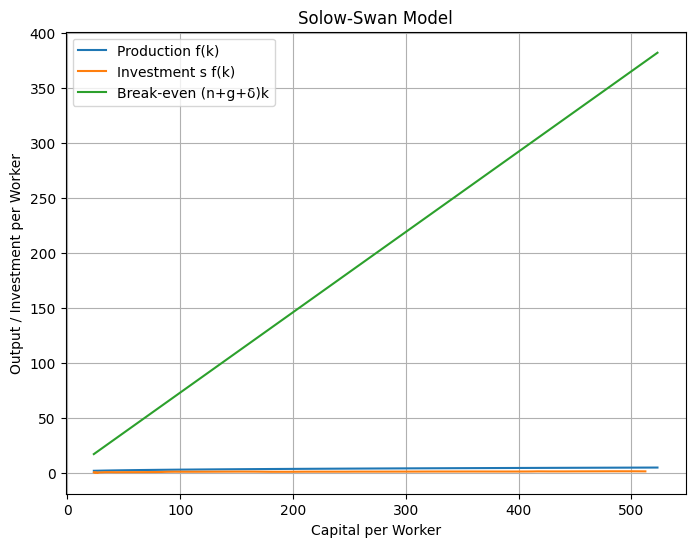

In [ ]:
plt.figure(figsize=(8,6))


sns.lineplot(x=k_actual, y= y_per_capita , label='Production f(k)')

sns.lineplot(x=k_actual, y=s_f_k_values, label='Investment s f(k)')
sns.lineplot(x=k_actual, y=break_even, label='Break-even (n+g+δ)k')

plt.xlabel("Capital per Worker")
plt.ylabel("Output / Investment per Worker")
plt.title("Solow-Swan Model")
plt.legend()
plt.grid()

plt.show()

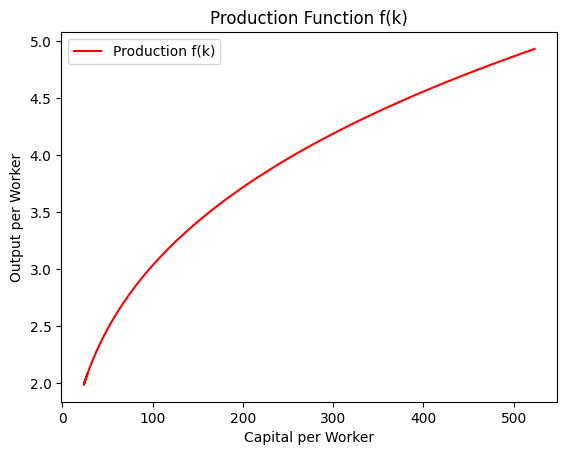

In [ ]:
plt.plot(df['k_actual'], y_per_capita, label='Production f(k)', color='red')
plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function f(k)") 
plt.legend()
plt.show()

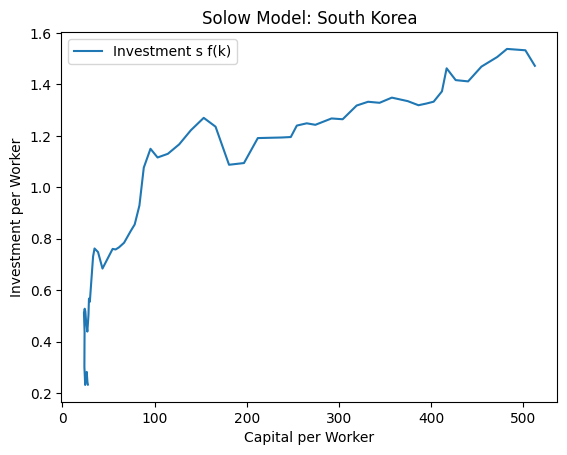

In [ ]:
plt.plot(k_actual, s_f_k_values , label='Investment s f(k)')
plt.xlabel("Capital per Worker")
plt.ylabel("Investment per Worker")
plt.title("Solow Model: South Korea")
plt.legend()
plt.show()

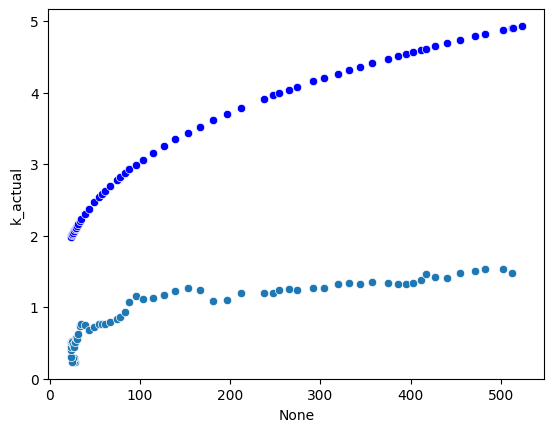

In [ ]:
sns.scatterplot(x= k_actual, y=y_per_capita, color='blue')
sns.scatterplot(x=k_actual, y=s_f_k_values)
plt.show()

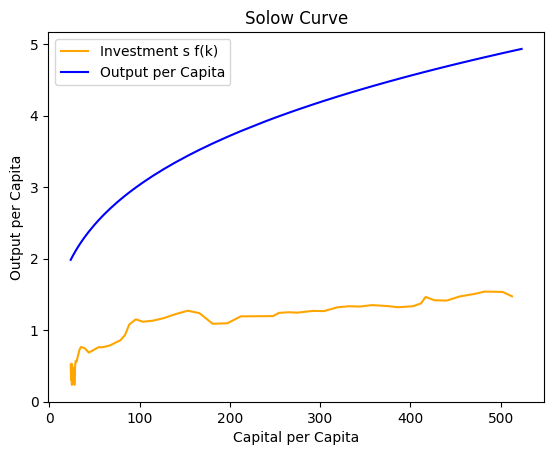

In [ ]:

# add breakeven investment line

sns.lineplot(x=k_actual, y=s_f_k_values, color='orange', label='Investment s f(k)')
sns.lineplot(x=k_actual, y=y_per_capita, color='blue', label='Output per Capita')

plt.title('Solow Curve')
plt.xlabel('Capital per Capita')
plt.ylabel('Output per Capita')
plt.show()

0.24498836133323793


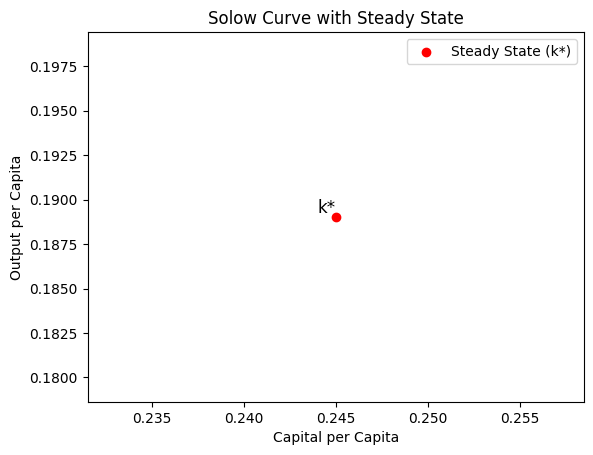

In [ ]:
# k star 

k_star = (s_mean / n_g_delta_avg) ** (1/(1-alpha))
print(k_star)

plt.scatter(k_star, s_mean * (k_star ** alpha), color='red', label='Steady State (k*)')
plt.text(k_star, s_mean * (k_star ** alpha), 'k*', fontsize=12, verticalalignment='bottom', horizontalalignment='right')

plt.title('Solow Curve with Steady State')
plt.xlabel('Capital per Capita')    
plt.ylabel('Output per Capita')
plt.legend()
plt.show()


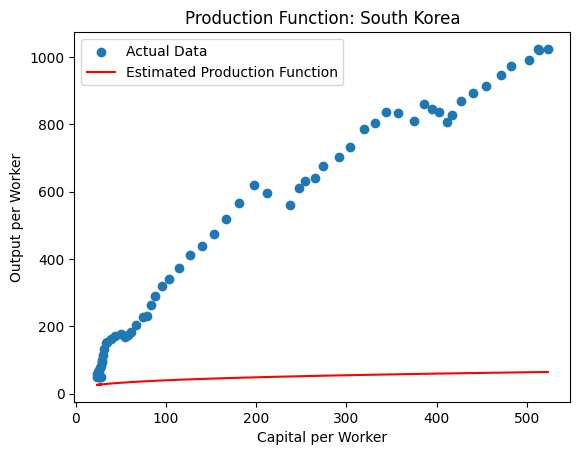

In [ ]:
df['y_actual'] = (df['rgdpo']/100) / df['emp']
df['k_actual'] = (df['rnna']/1000) / df['emp']

plt.scatter(df['k_actual'], df['y_actual'], label='Actual Data')

# k_grid = np.linspace(df['k_actual'].min(), df['k_actual'].max(), 200)
y_theory = np.exp(A) * k**alpha

plt.plot(k, y_theory, color='red', label='Estimated Production Function')

plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function: South Korea")
plt.legend()
plt.show()



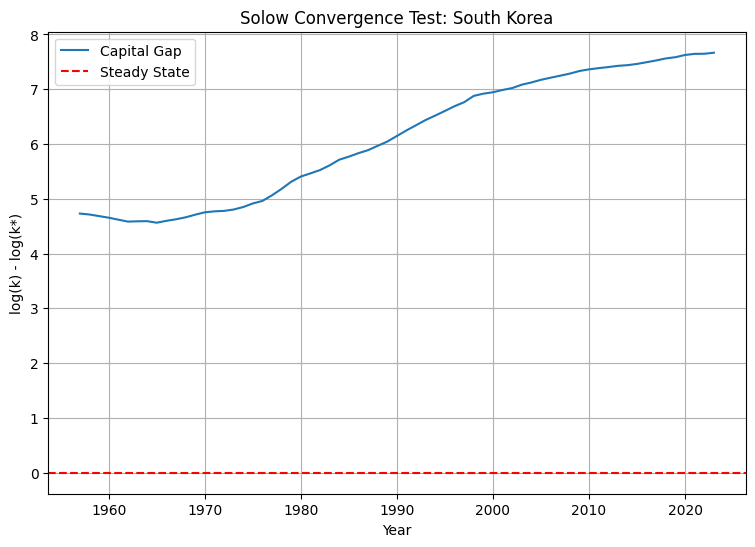

In [ ]:
df['capital_gap'] = np.log(df['k_actual']) - np.log(k_star)

plt.figure(figsize=(9,6))

plt.plot(df.index.year, df['capital_gap'], label='Capital Gap')

plt.axhline(0, color='red', linestyle='--', label='Steady State')

plt.title("Solow Convergence Test: South Korea")
plt.xlabel("Year")
plt.ylabel("log(k) - log(k*)")
plt.legend()
plt.grid()

plt.show()

## Break-even regression to identify structural changes